In [1]:
import cv2 as cv
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [2]:
def show_img(img, title: str = '') -> None:
    plt.imshow(img, 'gray')
    plt.title(title)
    plt.show()


In [25]:
img = cv.imread("./2_sift.png")
rgb_planes = cv2.split(img)
result_planes = []
result_norm_planes = []
for plane in rgb_planes:
    dilated_img = cv.dilate(plane, np.ones((7,7), np.uint8))
    bg_img = cv.medianBlur(dilated_img, 51)
    diff_img = 255 - cv.absdiff(plane, bg_img)
    norm_img = cv.normalize(diff_img, None, alpha=0, beta=255, norm_type=cv.NORM_MINMAX, dtype=cv.CV_8UC1)
    result_planes.append(diff_img)
    result_norm_planes.append(norm_img)

result = cv.merge(result_planes)
result_norm = cv.merge(result_norm_planes)

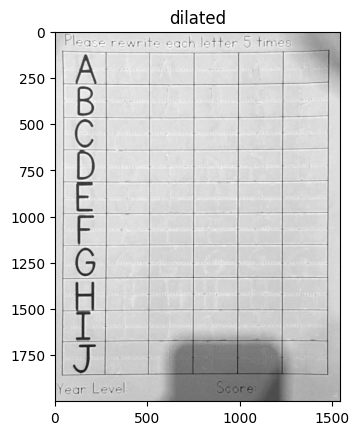

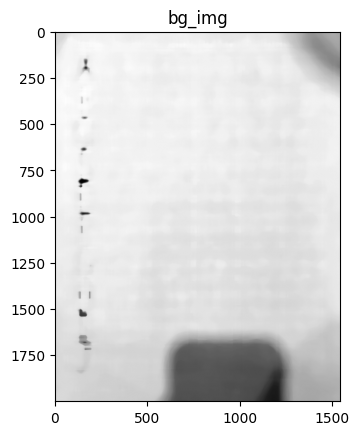

True

In [26]:
show_img(dilated_img, "dilated")
show_img(bg_img, "bg_img")
cv.imwrite('./flat_field.jpg', bg_img)

In [27]:
# gamma = 1.0
# lookUpTable = np.empty((1,256), np.uint8)
# for i in range(256):
#     lookUpTable[0,i] = np.clip(pow(i / 255.0, gamma) * 255.0, 0, 255)

# res = cv.LUT(result_norm, lookUpTable)

In [28]:
# def remove_shadow(img):
#     rgb_planes = cv.split(img)
#     result_planes = []
#     result_norm_planes = []
#     for plane in rgb_planes:
#         dilated_img = cv.dilate(plane, np.ones((7,7), np.uint8))
#         bg_img = cv.medianBlur(dilated_img, 101)
#         diff_img = 255 - cv.absdiff(plane, bg_img)
#         norm_img = cv.normalize(diff_img, None, alpha=0, beta=255, norm_type=cv.NORM_MINMAX, dtype=cv.CV_8UC1)
#         result_planes.append(diff_img)
#         result_norm_planes.append(norm_img)

#     result = cv.merge(result_planes)
#     result_norm = cv.merge(result_norm_planes)

#     return result_norm


In [29]:
edges = cv2.Canny(img, threshold1=100, threshold2=150)

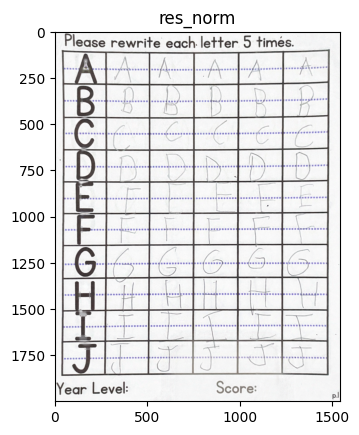

True

In [30]:
show_img(result_norm, "res_norm")
cv.imwrite("res_norm_test.png", result_norm)

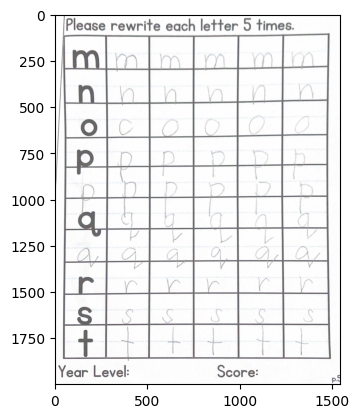

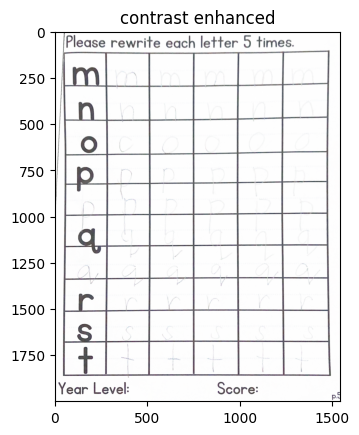

In [9]:
# import cv2


# Display the original and enhanced images
# cv2.imshow('Original', image)
# cv2.imshow('Enhanced', output)
# cv2.waitKey(0)
show_img(result_norm)
shadow_iter = result_norm
for _ in range (3):
    shadow_iter = remove_shadow(shadow_iter)
# show_img(shadow_removed_iter2)

# Source - https://stackoverflow.com/a/59515544
# Posted by Vardan Agarwal
# Retrieved 2026-02-05, License - CC BY-SA 4.0

import cv2
import numpy as np

# img = result_norm
# original = img.copy()
xp = [0, 64, 128, 192, 255]
fp = [0, 16, 128, 240, 255]
x = np.arange(256)
table = np.interp(x, xp, fp).astype('uint8')
contrast_img = cv2.LUT(shadow_iter, table)
show_img(contrast_img, 'contrast enhanced')

# show_img(contrast_stretched_image)
# cv.imwrite("contrast_img.png", contrast_stretched_image)

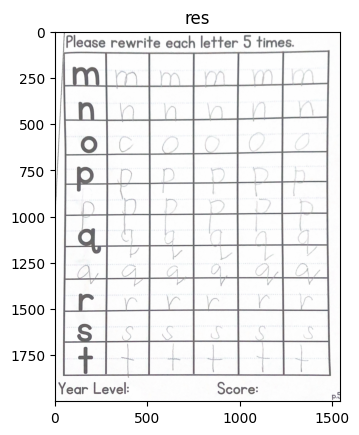

In [10]:
show_img(result, 'res')
# cv.imwrite("res_norm_gamma.png", result_norm)

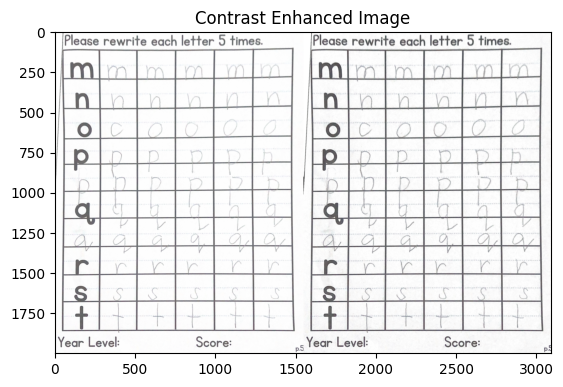

In [11]:
lab = cv2.cvtColor(result_norm, cv2.COLOR_BGR2LAB)
l_channel, a, b = cv2.split(lab)

# Apply CLAHE to the L-channel
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
cl = clahe.apply(l_channel)

# Merge modified L-channel back with a and b channels
limg = cv2.merge((cl, a, b))

# Convert back to BGR color space
enhanced_img = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

# Show original and enhanced images side by side
result = np.hstack((result_norm, enhanced_img))
# cv2.imshow('Contrast Enhanced Image', result)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
show_img(result, 'Contrast Enhanced Image')

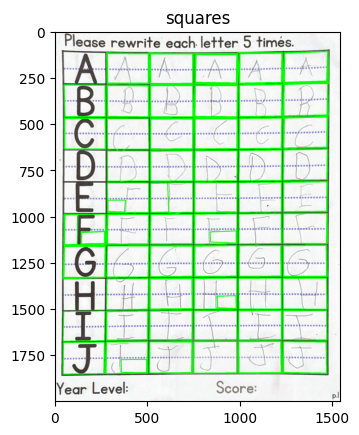

768
Done


In [12]:
# https://github.com/opencv/opencv/blob/master/samples/python/squares.py

'''
Simple "Square Detector" program.

Loads several images sequentially and tries to find squares in each image.
'''

# Python 2/3 compatibility
# from __future__ import print_function
import numpy as np
import cv2 as cv

def angle_cos(p0, p1, p2):
    d1, d2 = (p0-p1).astype('float'), (p2-p1).astype('float')
    return abs( np.dot(d1, d2) / np.sqrt( np.dot(d1, d1)*np.dot(d2, d2) ) )

def find_squares(img):
    img = cv.GaussianBlur(img, (5, 5), 0)
    squares = []
    h, w = img.shape[:2]
    img_area = h*w
    for gray in cv.split(img):
        for thrs in range(0, 255, 26):
            if thrs == 0:
                bin = cv.Canny(gray, 0, 50, apertureSize=5)
                bin = cv.dilate(bin, None)
            else:
                _retval, bin = cv.threshold(gray, thrs, 255, cv.THRESH_BINARY)
            contours, _hierarchy = cv.findContours(bin, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)
            for cnt in contours:
                cnt_len = cv.arcLength(cnt, True)
                cnt = cv.approxPolyDP(cnt, 0.02*cnt_len, True)
                if len(cnt) == 4 and cv.contourArea(cnt) > 5000 and cv.contourArea(cnt) < img_area * 0.5 and cv.isContourConvex(cnt):
                    cnt = cnt.reshape(-1, 2)
                    max_cos = np.max([angle_cos( cnt[i], cnt[(i+1) % 4], cnt[(i+2) % 4] ) for i in range(4)])
                    if max_cos < 0.1:
                        squares.append(cnt)
    return squares


# from glob import glob
# for fn in glob('../data/pic*.png'):
img = cv.imread('./removed_shadow.png')
squares = find_squares(img)
cv.drawContours( img, squares, -1, (0, 255, 0), 3 )
show_img(img, 'squares')
print(len(squares))
    # cv.imshow('squares', img)


print('Done')


# if __name__ == '__main__':
#     print(__doc__)
#     main()
    # cv.destroyAllWindows()

In [13]:
squares[0]

array([[ 357, 1776],
       [ 359, 1845],
       [ 494, 1846],
       [ 494, 1774]], dtype=int32)

In [14]:
def count_grid_cells(img) -> int:
    """
    Automatically detects and counts grid cells in the image.
    Returns the number of cells found.
    """
    # Convert to grayscale if needed
    if len(img.shape) == 3:
        img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    else:
        img_gray = img
    
    # Apply threshold to detect grid lines
    # _, binary = cv.threshold(img_gray, 200, 255, cv.THRESH_BINARY_INV)

    binary = cv.adaptiveThreshold(
        img_gray, 
        255, 
        cv.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv.THRESH_BINARY_INV, 
        15, 
        10
    )
    # show_img(binary)
    # Find contours
    contours, _ = cv.findContours(binary, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
    
    cell_count = 0
    img_area = img_gray.shape[0] * img_gray.shape[1]
    squares = []
    for contour in contours:
        area = cv.contourArea(contour)
        
        # Filter: cells should be reasonably sized (not too small, not the whole image)
        if area > 1000 and area < img_area * 0.5:
            # Approximate the contour to see if it's rectangular
            peri = cv.arcLength(contour, True)
            approx = cv.approxPolyDP(contour, 0.02 * peri, True)
            
            # If it has 4 corners (rectangle)
            if len(approx) == 4:
                x, y, w, h = cv.boundingRect(contour)
                # Check aspect ratio is reasonable for a cell
                squares.append(contour)
                # aspect_ratio = float(w) / h if h > 0 else 0
                # if 0.3 < aspect_ratio < 3.0:  
                cell_count += 1
    cv.drawContours(img, squares, -1, (0,255,0), 3)
    show_img(img, 'squares')
    print(f"Number of grid cells detected: {cell_count}")
    return cell_count



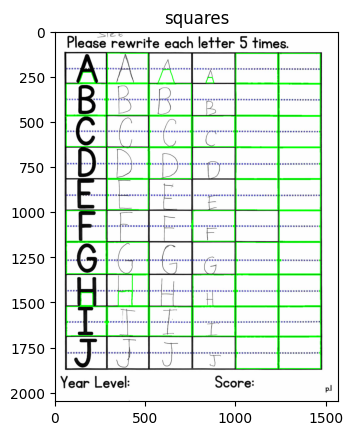

Number of grid cells detected: 44


44

In [15]:
img = cv.imread('./worksheets/A-J_size.jpg')
count_grid_cells(img)